In [1]:
import math
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [2]:
a = [2, 3, 1, 2, 4, 5, 1]
b = [2, 3, 5, 1]
max_len = 20
a_split = max_len //2
a[:a_split] + b[:max_len - a_split]

[2, 3, 1, 2, 4, 5, 1, 2, 3, 5, 1]

In [2]:
def get_random_word(vocab_words):
    i = random.randint(0, len(vocab_words)-1)
    return vocab_words[i]

In [3]:
from collections import Counter
def preprocess(line):
    return line.lower().split()
PAD_IDX = 0
CLS_IDX = 1
SEP_IDX = 2
MASK_IDX = 3
UNK_IDX = 4
class Vocab:
    def __init__(self, file=None):
        self.c = Counter()
        self.word2idx = {
            "<pad>": PAD_IDX,
            "<cls>": CLS_IDX,
            "<sep>": SEP_IDX,
            "<mask>": MASK_IDX,
            "<unk>": UNK_IDX,
        }
        self.idx2word = {
            PAD_IDX: "<pad>",
            CLS_IDX: "<cls>",
            SEP_IDX: "<sep>",
            MASK_IDX: "<mask>",
            UNK_IDX: "<unk>",
        }
        if file is not None:
            self._update(file)
    def _update(self, file):
        with open(file, "r", encoding="utf-8") as f:
            for line in f:
                self.c.update(preprocess(line))
        # Add only words that aren't already in the vocabulary
        for word, _ in sorted(
            self.c.items(),
            key=lambda item: (-item[1], item[0])
        ):
            if word not in self.word2idx:
                idx = len(self.word2idx)
                self.word2idx[word] = idx
                self.idx2word[idx] = word
    def __len__(self):
        return len(self.word2idx)
    def __getitem__(self, word):
        return self.word2idx.get(word, UNK_IDX)
    def encode(self, line):
        return [self[word] for word in preprocess(line)]
    def decode(self, indices):
        return [self.idx2word.get(i, "<unk>") for i in indices]

vocab = Vocab("train_data.txt")
len(vocab)

28915

In [20]:
vocab._update("val_data.txt")
vocab._update("test_data.txt")
len(vocab)

28915

In [21]:
indexer = vocab.encode
indexer("I am a good boy")

[76, 1740, 12, 429, 1369]

In [ ]:
class PipelineForPretrain:
    def __init__(self, vocab_words, indexer, max_pred=20, mask_prob=0.15, max_len=512):
        super().__init__()
        self.max_len = max_len
        self.max_pred = max_pred
        self.mask_prob = mask_prob
        self.vocab_words = vocab_words # list(vocab.word2idx.keys())
        self.indexer = indexer # function of vocab.__getitem__
        self.max_len = max_len
    def __call__(self, instance):
        is_not_next, tokens_a, tokens_b = instance
        # max_len - 3
        a_split = (self.max_len - 3) // 2
        b_split = self.max_len - 3 - a_split
        tokens_a = tokens_a[:a_split]
        tokens_b = tokens_b[:b_split]
        tokens = ['<cls>'] + tokens_a + ['<sep>'] + tokens_b + ['<sep>']
        segment_ids = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)
        input_mask = [1] * len(tokens)
        
        # masked language model
        masked_tokens, masked_pos = [], []
        n_pred = min(self.max_pred, max(1, round(len(tokens) * self.mask_prob)))
        cand_pos = [i for i, token in enumerate(tokens)
                    if token != '<cls>' and token != '<sep>']
        random.shuffle(cand_pos)
        for pos in cand_pos[:n_pred]:
            masked_tokens.append(tokens[pos])
            masked_pos.append(pos)
            if random.random() < 0.8: # 80%
                tokens[pos] = '<mask>'
            elif random.random() < 0.5: # 10%
                tokens[pos] = get_random_word(self.vocab_words)
        masked_weights = [1] * len(masked_tokens)

        input_ids = self.indexer(tokens)
        masked_ids = self.indexer(masked_tokens)

        n_pad = self.max_len - len(input_ids)
        input_ids.extend([0] * n_pad)
        segment_ids.extend([0] * n_pad)
        input_mask.extend([0] * n_pad)

        if self.max_pred > n_pred:
            n_pad = self.max_pred - n_pred
            masked_ids.extend([0] * n_pad)
            masked_pos.extend([0] * n_pad)
            masked_weights.extend([0] * n_pad)
        
        return (input_ids, segment_ids, input_mask, masked_ids, masked_pos, masked_weights, is_not_next)

class SentencePairDataLoader:
    def __init__(self, file, pipeline, batch_size=32, max_len=512):
        self.max_len=max_len
        self.batch_size=batch_size
        self.short_sampling_prob=0.1
        with open(file, "r") as f:
            self.lines = f.readlines()
        self.a_pos = 0
        self.tot_lines = len(self.lines)
        self.pipeline = pipeline
    def read_tokens(self, line_number, length):
        flag = False # check if line number is changed or not
        while True:
            line = self.lines[line_number]
            tokens = preprocess(line)
            if not tokens or tokens[0] == '=':
                line_number = (line_number + 1) % self.tot_lines
                flag = True
                continue
            break
        tokens = tokens[:length]
        line_number = (line_number + 1) % self.tot_lines
        return tokens, line_number, flag
    def set_random_offset(self):
        return random.randint(0, self.tot_lines - 1)
    def __len__(self):
        return self.tot_lines // self.batch_size
    def __iter__(self):
        self.a_pos = 0
        for _ in range(len(self)):
            batch = []
            for _ in range(self.batch_size):
                len_tokens = random.randint(1, int(self.max_len / 2)) if random.random() < self.short_sampling_prob else int(self.max_len / 2)
                is_not_next = random.random() < 0.5
                tokens_a, self.a_pos, _ = self.read_tokens(self.a_pos, len_tokens)
                b_next = self.set_random_offset() if is_not_next else self.a_pos + 1
                if b_next == self.tot_lines:
                    b_next = 0
                tokens_b, _, fg = self.read_tokens(b_next, len_tokens)
                flag = (b_next != (self.a_pos + 1)) or fg
                if flag is True:
                    is_not_next = True
                instance = (is_not_next, tokens_a, tokens_b)
                for proc in self.pipeline:
                    instance = proc(instance)
                batch.append(instance)
            batch_tensors = [torch.tensor(x, dtype=torch.long) for x in zip(*batch)]
            yield batch_tensors

In [4]:
MAX_LEN = 256

In [ ]:
def indexer(words: list[str]):
    return [vocab.__getitem__(word) for word in words]
pipeline = [PipelineForPretrain(vocab_words=list(vocab.word2idx.keys()), indexer=indexer, max_len=MAX_LEN)]
BATCH_SIZE=16
train_loader = SentencePairDataLoader("train_data.txt", pipeline=pipeline, batch_size=BATCH_SIZE, max_len=MAX_LEN)
val_loader = SentencePairDataLoader("val_data.txt", pipeline=pipeline, batch_size=BATCH_SIZE, max_len=MAX_LEN)

In [ ]:
input_ids, segment_ids, input_mask, masked_ids, masked_pos, masked_weights, is_not_next = next(iter(train_loader))
print(input_ids[0])

In [5]:
gelu = lambda x : x * 0.5 * (1.0 + torch.erf(x / math.sqrt(2.0)))
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, dim=768, dropout=0.1, n_heads=12):
        super().__init__()
        self.proj_q = nn.Linear(dim, dim)
        self.proj_k = nn.Linear(dim, dim)
        self.proj_v = nn.Linear(dim, dim)
        self.drop = nn.Dropout(dropout)
        self.scores = None
        self.n_heads = n_heads
    def forward(self, x, mask):
        # x: b,s,d, mask: b,s
        b, s, d = x.shape
        # b, s, d -> b, s, d
        q, k, v = self.proj_q(x), self.proj_k(x), self.proj_v(x)
        # b, s, d -> b, s, h, w -> b, h, s, w
        q = q.reshape(b, s, self.n_heads, -1).transpose(1, 2)
        k = k.reshape(b, s, self.n_heads, -1).transpose(1, 2)
        v = v.reshape(b, s, self.n_heads, -1).transpose(1, 2)
        # b, h, s, w @ b, h, w, s = b, h, s, s
        scores = q @ k.transpose(-2, -1) /  np.sqrt(d // self.n_heads)
        if mask is not None:
            mask = mask[:, None, None, :].float() # b, 1, 1, s
            scores -= 10000.0 * (1.0 - mask)
        scores = self.drop(nn.functional.softmax(scores, dim=-1))
        h = (scores @ v).transpose(1, 2).contiguous() # b, s, h, w
        h = h.reshape(b, s, d)
        self.scores = scores
        return h
class PositionWiseFF(nn.Module):
    def __init__(self, dim=768, dim_ff=3072):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim_ff)
        self.fc2 = nn.Linear(dim_ff, dim)
    def forward(self, x):
        return self.fc2(gelu(self.fc1(x)))
class LayerNorm(nn.Module):
    def __init__(self, dim=768, variance_epsilon=1e-12):
        super().__init__()
        self.gamma = nn.Parameter(torch.ones(dim))
        self.beta = nn.Parameter(torch.zeros(dim))
        self.variance_epsilon = variance_epsilon
    def forward(self, x):
        u = x.mean(-1, keepdim=True)
        s = (x - u).pow(2).mean(-1, keepdim=True)
        x = (x - u) / torch.sqrt(s + self.variance_epsilon)
        return self.gamma * x + self.beta

In [6]:
def Embedding(num_emb, emb_dim, padding_idx=None):
    m = nn.Embedding(num_emb, emb_dim, padding_idx)
    nn.init.normal_(m.weight, mean=0, std=emb_dim ** -0.5)
    nn.init.constant_(m.weight[padding_idx], 0)
    return m
class Embeddings(nn.Module):
    def __init__(self, vocab_size, dim=768, max_len=512, n_segments=2, position_embeds=True, segment_embeds=True, dropout=0.1):
        super().__init__()
        self.tok_embed = Embedding(vocab_size, dim)
        self.pos_embed = Embedding(max_len, dim) if position_embeds else None
        self.seg_embed = Embedding(n_segments, dim) if segment_embeds else None
        self.norm = LayerNorm(dim)
        self.drop = nn.Dropout(dropout)
    def forward(self, x, seg):
        e = self.tok_embed(x)
        if self.pos_embed is not None:
            pos = torch.arange(x.size(1), dtype=torch.long, device=x.device)
            pos = pos.unsqueeze(0).expand_as(x)
            e = e + self.pos_embed(pos)
        if self.seg_embed is not None:
            e = e + self.seg_embed(seg)
        return self.drop(self.norm(e))
class Block(nn.Module):
    def __init__(self, dim=768, dim_ff=3072, n_heads=12, dropout=0.1):
        super().__init__()
        self.attn = MultiHeadSelfAttention(dim, dropout, n_heads)
        self.proj = nn.Linear(dim, dim)
        self.norm1 = LayerNorm(dim)
        self.pwff = PositionWiseFF(dim, dim_ff)
        self.norm2 = LayerNorm(dim)
        self.drop = nn.Dropout(dropout)
    def forward(self, x, mask):
        h = self.attn(x, mask)
        h = self.norm1(x + self.drop(self.proj(h)))
        h = self.norm2(h + self.drop(self.pwff(h)))
        return h
class BERT(nn.Module):
    def __init__(self, vocab_size, dim=768, dim_ff=3072, max_len=512, n_heads = 12, n_layers=12, dropout=0.1):
        super().__init__()
        self.dim = dim
        self.embed = Embeddings(vocab_size, dim, max_len)
        self.blocks = nn.ModuleList([Block(dim, dim_ff, n_heads, dropout) for _ in range(n_layers)])
    def forward(self, x, seg, mask):
        h = self.embed(x, seg)
        for block in self.blocks:
            h = block(h, mask)
        return h

In [7]:
class BERTPretrain(nn.Module):
    def __init__(self, transformer: BERT):
        super().__init__()
        self.transformer = transformer
        dim = transformer.dim
        # for sentence classification
        self.pooler = nn.Linear(dim, dim)
        self.pooler_activation = nn.Tanh()
        self.seq_relationship = nn.Linear(dim, 2)

        # for masked LM
        embed_weight = self.transformer.embed.tok_embed.weight
        n_vocab, n_dim = embed_weight.size()
        self.decoder_linear = nn.Linear(dim, dim)
        self.decoder_norm = LayerNorm(dim)
        self.decoder_output = nn.Linear(n_dim, n_vocab, bias=False)
        self.decoder_output_bias = nn.Parameter(torch.zeros(n_vocab))

        self.decoder_output.weights = self.transformer.embed.tok_embed.weight
    def forward(self, input_ids, segment_ids=None, input_mask=None, masked_pos=None):
        segment_ids = torch.zeros_like(input_ids) if segment_ids is None else segment_ids
        input_mask = torch.ones_like(input_ids) if input_mask is None else input_mask
        h = self.transformer(input_ids, segment_ids, input_mask)

        # sentence classification
        pooled_h = self.pooler_activation(self.pooler(h[:, 0]))
        logits_clsf = self.seq_relationship(pooled_h)

        # for masked lm
        masked_pos = masked_pos[:, :, None].expand(-1, -1, h.size(-1))
        h_masked = h if masked_pos is None else torch.gather(h, 1, masked_pos)
        h_masked = self.decoder_norm(gelu(self.decoder_linear(h_masked)))
        logits_lm = self.decoder_output(h_masked) + self.decoder_output_bias
        return logits_lm, logits_clsf

class BERTClassification(nn.Module):
    def __init__(self, transformer: BERT, num_classes):
        super().__init__()
        self.transformer = transformer
        dim = transformer.dim
        self.pooler = nn.Linear(dim, dim)
        self.pooler_activation = nn.Tanh()
        self.dropout = nn.Dropout(0.1)
        self.classifier = nn.Linear(dim, num_classes)
    def forward(self, input_ids, segment_ids=None, input_mask=None):
        segment_ids = torch.zeros_like(input_ids) if segment_ids is None else segment_ids
        input_mask = torch.ones_like(input_ids) if  input_mask is None else input_mask
        h = self.transformer(input_ids, segment_ids, input_mask)
        pooled_h = self.pooler_activation(self.pooler(h[:, 0]))
        pooled_h = self.dropout(pooled_h)
        logits = self.classifier(pooled_h)
        return logits

In [28]:
body = BERT(vocab_size=len(vocab), dim=256, dim_ff=1024, n_layers=4, n_heads=4, max_len=MAX_LEN)
model = BERTPretrain(body)

In [29]:
from tqdm import tqdm
def train_epoch(model, dataloader, optimizer, epoch, device):
    model.train()
    total_loss = 0.0
    total_steps = 0
    for batch in tqdm(dataloader, desc=f"[Epoch {epoch+1:3d}] Batch "):
        batch = tuple(t.to(device) for t in batch)
        input_ids, segment_ids, input_mask, masked_ids, masked_pos, masked_weights, is_not_next = batch
        logits_lm, logits_sc = model(input_ids, segment_ids, input_mask, masked_pos)
        loss_lm = nn.functional.cross_entropy(logits_lm.transpose(1, 2), masked_ids, reduction='none')
        loss_lm = (loss_lm * masked_weights.float()).mean()
        loss_sc = nn.functional.cross_entropy(logits_sc, is_not_next)
        loss = loss_lm + loss_sc
        loss.backward()
        total_loss += loss.item()
        total_steps += 1
        optimizer.step()
        optimizer.zero_grad()
    train_loss = total_loss / total_steps
    # print(f"Train loss: {train_loss}")
    return train_loss
def evaluate(model, dataloader, device):
    model.eval()
    total_loss = 0.0
    total_steps = 0
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Validation "):
            batch = tuple(t.to(device) for t in batch)
            input_ids, segment_ids, input_mask, masked_ids, masked_pos, masked_weights, is_not_next = batch
            logits_lm, logits_sc = model(input_ids, segment_ids, input_mask, masked_pos)
            loss_lm = nn.functional.cross_entropy(logits_lm.transpose(1, 2), masked_ids, reduction='none')
            loss_lm = (loss_lm * masked_weights.float()).mean()
            loss_sc = nn.functional.cross_entropy(logits_sc, is_not_next)
            loss = loss_lm + loss_sc
            total_loss += loss.item()
            total_steps += 1
    val_loss = total_loss / total_steps
    # print(f"Val loss: {val_loss}")
    return val_loss

In [ ]:
train_losses = []
val_losses = []
optimizer = torch.optim.AdamW(params=model.parameters())
model = model.to(device)
NUM_EPOCHS=50
for epoch in range(NUM_EPOCHS):
    train_loss = train_epoch(model, train_loader, optimizer, epoch, device)
    val_loss = evaluate(model, val_loader, device)
    print(f"Epoch: {epoch + 1:2d}, Train loss: {train_loss:.4f}, Val loss: {val_loss:.4f}")
    train_losses.append(train_loss)
    val_losses.append(val_loss)

In [31]:
torch.save(body.state_dict(), "bert-sbjt.pt")

In [8]:
body = BERT(vocab_size=len(vocab), dim=256, dim_ff=1024, n_layers=4, n_heads=4, max_len=MAX_LEN)
body.load_state_dict(torch.load("bert-sbjt.pt"))
print("loaded")

loaded


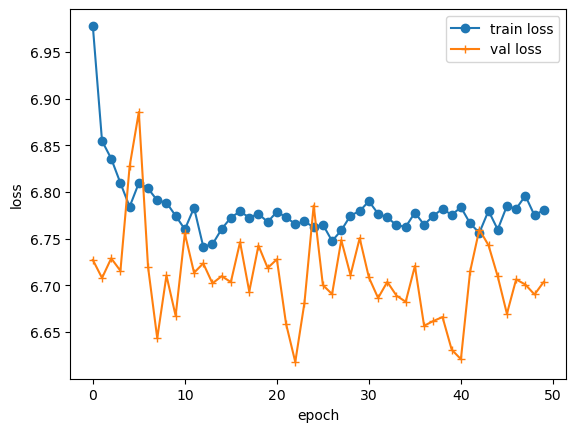

In [35]:
import matplotlib.pyplot as plt
plt.plot(train_losses, marker='o', label='train loss')
plt.plot(val_losses, marker='+', label='val loss')
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

```bash
output_modes = {
    "cola": "classification",
    "mnli": "classification",
    "mrpc": "classification",
    "sst-2": "classification",
    "sts-b": "regression",
    "qqp": "classification", # quora question pairs <- procedding with this
    "qnli": "classification",
    "rte": "classification",
    "wnli": "classification",
    "psychexp": "classification",
}
```

In [9]:
df_train = pd.read_parquet("train-00000-of-00001.parquet", engine="pyarrow")
df_val = pd.read_parquet("validation-00000-of-00001.parquet", engine="pyarrow")

In [8]:
len(df_train), len(df_val)

(363846, 40430)

In [3]:
x = list(range(len(df_train)))
random.shuffle(x)
df_train.iloc[0]

question1    How is the life of a math student? Could you d...
question2    Which level of prepration is enough for the ex...
label                                                        0
idx                                                          0
Name: 0, dtype: object

In [8]:
a = [2, 1, 0, 3]
df_train.iloc[2]

question1         What causes stool color to change to yellow?
question2    What can cause stool to come out as little balls?
label                                                        0
idx                                                          2
Name: 2, dtype: object

In [10]:
class QQPDataloader:
    def __init__(self, df: pd.DataFrame, text2ids, batch_size=32, max_len=128):
        self.df = df
        self.batch_size = batch_size
        self.df_len = len(df)
        self.text2ids = text2ids
        self.ids = list(range(len(df)))
        random.shuffle(self.ids)
        self.pos = 0
        self.max_len = max_len
    def __len__(self):
        return self.df_len // self.batch_size
    def __iter__(self):
        for _ in range(len(self)):
            batch = []
            indices = self.ids[self.pos:self.pos+self.batch_size]
            for i in indices:
                q1 = self.df.iloc[i]['question1']
                q2 = self.df.iloc[i]['question2']
                q1 = self.text2ids(q1)
                # print(q1)
                q2 = self.text2ids(q2)
                # <cls> q1 <sep> q2 <sep> <pad>
                q1_split = (self.max_len - 3) // 2
                q1 = q1[:q1_split]
                q2 = q2[:self.max_len - 3 - q1_split]
                tokens = self.text2ids("<cls>") + q1 + self.text2ids("<sep>") + q2 + self.text2ids("<sep>")
                segment_ids = [0] * (len(q1) + 2) + [1] * (len(q2) + 1)
                input_mask = [1] * len(tokens)
                label = self.df.iloc[i]['label']
                n_pad = self.max_len - len(tokens)
                tokens.extend([0] * n_pad)
                segment_ids.extend([0] * n_pad)
                input_mask.extend([0] * n_pad)
                batch.append((tokens, segment_ids, input_mask, label))
            batch_tensors = [torch.tensor(x, dtype=torch.long) for x in zip(*batch)]
            yield batch_tensors

In [11]:
train_loader = QQPDataloader(df_train, vocab.encode)
val_loader = QQPDataloader(df_val, vocab.encode)

In [6]:
len(train_loader), len(val_loader)

(11370, 1263)

In [12]:
from tqdm import tqdm
def train_epoch(model: BERTClassification, dataloader, optimizer, epoch, device):
    model.train()
    total_loss = 0.0
    total_steps = 0
    criterion = nn.CrossEntropyLoss()
    for batch in tqdm(dataloader, desc=f"[Epoch {epoch+1:3d}] Batch "):
        batch = tuple(t.to(device) for t in batch)
        tokens, segment_ids, input_mask, labels = batch
        logits = model(tokens, segment_ids, input_mask)
        loss = criterion(logits, labels)
        # print("labels:", labels)
        # print("logits:", logits)
        # print("loss:", loss.item())
        loss.backward()
        total_loss += loss.item()
        total_steps += 1
        optimizer.step()
        optimizer.zero_grad()
    train_loss = total_loss / total_steps
    # print(f"Train loss: {train_loss}")
    return train_loss
def evaluate(model: BERTClassification, dataloader, device):
    model.eval()
    total_loss = 0.0
    total_steps = 0
    criterion = nn.CrossEntropyLoss()
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Validation "):
            batch = tuple(t.to(device) for t in batch)
            tokens, segment_ids, input_mask, labels = batch
            logits = model(tokens, segment_ids, input_mask)
            loss = criterion(logits, labels)
            total_loss += loss.item()
            total_steps += 1
    val_loss = total_loss / total_steps
    # print(f"Val loss: {val_loss}")
    return val_loss

In [ ]:
model = BERTClassification(body, 2)
model = model.to(device)
optimizer = torch.optim.AdamW(model.parameters())
NUM_EPOCHS = 10
train_losses = []
val_losses = []
for epoch in range(NUM_EPOCHS):
    train_loss = train_epoch(model, train_loader, optimizer, epoch, device)
    val_loss = evaluate(model, val_loader, device)
    print(f"Train loss: {train_loss:.4f}, Val loss: {val_loss:.4f}")
    train_losses.append(train_loss)
    val_losses.append(val_loss)
import matplotlib.pyplot as plt
plt.plot(train_losses, marker='o', label='train_loss')
plt.plot(val_losses, marker='+', label='val_loss')
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

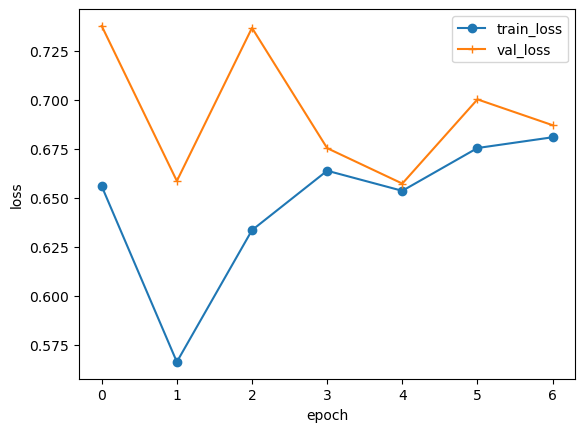

In [14]:
import matplotlib.pyplot as plt
plt.plot(train_losses, marker='o', label='train_loss')
plt.plot(val_losses, marker='+', label='val_loss')
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

In [15]:
torch.save(model.state_dict(), "bert-qqp-sbjt.pt")

In [29]:
def evaluate(model: BERTClassification, dataloader, device):
    model.eval()
    total_correct = 0
    total = 0
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Validation "):
            batch = tuple(t.to(device) for t in batch)
            tokens, segment_ids, input_mask, labels = batch
            logits = model(tokens, segment_ids, input_mask)
            preds = logits.argmax(dim=-1)
            total_correct += (preds == labels).sum()
            total += logits.size(0)
    # print(f"Val loss: {val_loss}")
    acc = total_correct / total
    return acc

In [30]:
acc = evaluate(model, val_loader, device)
print(f"Val acc: {acc*100:.2f}")

Validation : 100%|██████████| 1263/1263 [00:17<00:00, 70.60it/s]

Val acc: 31.25
